# 02. Calibration Validation

This notebook loads the exported `calibration.json` and `scenarios.parquet` files to validate our simulation transition dynamics.

In [1]:
import json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

with open('../data/processed/silverstone/calibration.json', 'r') as f:
    calib = json.load(f)

scenarios = pd.read_parquet('../data/processed/silverstone/scenarios.parquet')
print("Calibration fields:", list(calib.keys()))
print(f"Loaded {len(scenarios['race_id'].unique())} scenarios from scenarios.parquet")

# Color mapping for compounds as requested
tyre_colors = {
    "SOFT": "red",
    "MEDIUM": "yellow",
    "HARD": "black",
    "INTERMEDIATE": "green",
    "INTER": "green",
    "WET": "blue"
}

Calibration fields: ['circuit', 'total_laps', 'base_pace', 'pit_loss', 'noise_std', 'fuel', 'compounds', 'weather_compound_penalty', 'safety_car_probability_per_lap', 'safety_car_lap_time']
Loaded 3 scenarios from scenarios.parquet


## 1. Simulate and Compare Tyre Degradation Curves (Soft vs Medium vs Hard)

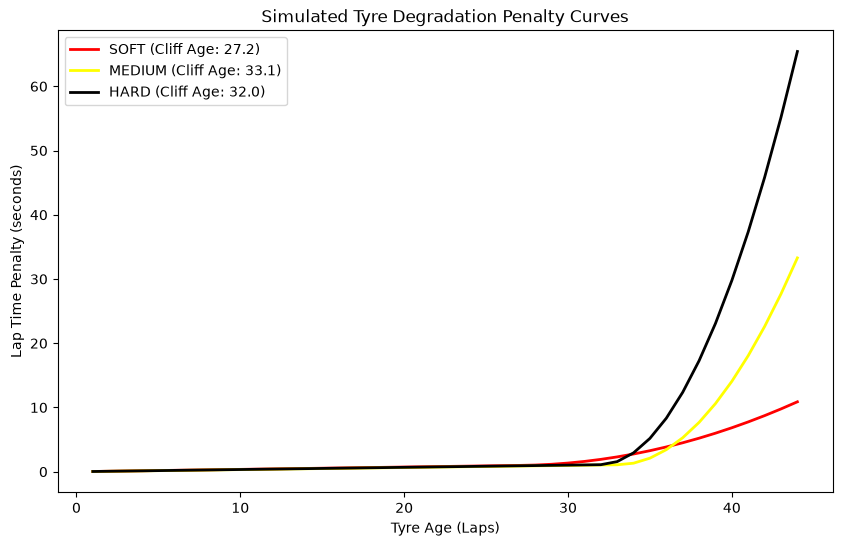

In [2]:
def sim_tyre_deg(compound, age, params):
    comp_params = params["compounds"][compound]
    base_deg = comp_params["base_deg"]
    cliff_age = comp_params["cliff_age"]
    cliff_sev = comp_params["cliff_severity"]
    
    gradual = base_deg * age
    cliff = cliff_sev * np.maximum(0, age - cliff_age) ** 2
    return gradual + cliff

ages = np.arange(1, 45)
plt.figure(figsize=(10, 6))
for comp in ["SOFT", "MEDIUM", "HARD"]:
    deg_vals = [sim_tyre_deg(comp, age, calib) for age in ages]
    plt.plot(ages, deg_vals, label=f"{comp} (Cliff Age: {calib['compounds'][comp]['cliff_age']})", color=tyre_colors[comp], lw=2)

plt.title("Simulated Tyre Degradation Penalty Curves")
plt.xlabel("Tyre Age (Laps)")
plt.ylabel("Lap Time Penalty (seconds)")
plt.legend()
plt.show()

## 2. Simulate Single Stint Lap Times

Shows the combined effect of fuel burn-off (car gets lighter/faster) and tire degradation (car gets slower).

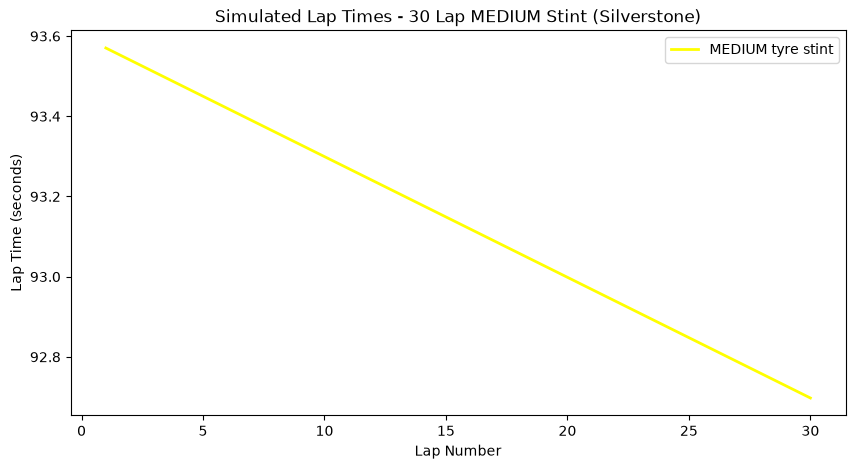

In [3]:
base_pace = calib["base_pace"]
fuel_burn = calib["fuel"]["consumption_kg_per_lap"]
fuel_sens = calib["fuel"]["sensitivity_s_per_kg"]
total_laps = calib["total_laps"]

def sim_lap_time(compound, age, lap_number):
    deg = sim_tyre_deg(compound, age, calib)
    laps_remaining = total_laps - lap_number
    fuel_kg = laps_remaining * fuel_burn
    fuel_eff = fuel_kg * fuel_sens
    return base_pace + deg + fuel_eff

# Simulate running 30 laps on MEDIUM from the start of the race
lap_numbers = np.arange(1, 31)
sim_times = [sim_lap_time("MEDIUM", age, age) for age in lap_numbers]

plt.figure(figsize=(10, 5))
plt.plot(lap_numbers, sim_times, label="MEDIUM tyre stint", color="yellow", lw=2)
plt.title("Simulated Lap Times - 30 Lap MEDIUM Stint (Silverstone)")
plt.xlabel("Lap Number")
plt.ylabel("Lap Time (seconds)")
plt.legend()
plt.show()